# Notebook 6: PSCSR and SmartSeq Latent Space Visualisations

This notebook generates latent space plots for PSCSR and SmartSeq test cells that were not
included in the main experiment notebooks.  It covers:
- **Figure 5a** — SmartSeq test cell clustering (model 5)
- **Figure 6bc** — PSCSR latent space under the TCGA+GTEx+R2 model (model 4b)
- **Supplementary Figure 8ab** — PSCSR latent space under the TCGA+GTEx+R2+SmartSeq model (model 5)


## Section 1: Library, Functions, and Data Loading

In [1]:
import sys
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.decomposition import PCA


In [2]:
from pathlib import Path

cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebook" else cwd
if not (repo_root / "models").is_dir():
    repo_root = next(
        p for p in (cwd, *cwd.parents)
        if (p / "models").is_dir() and (p / "notebook").is_dir()
    )
for p in (repo_root, repo_root / "notebook"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))


In [3]:
%load_ext autoreload
%autoreload 2
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['mathtext.default'] = 'regular'


In [4]:
from base.dgd.nn import NB_Module, ZINB_Module
from base.dgd.DGD import DGD
from base.dgd.latent import RepresentationLayer
from base.utils.helpers import set_seed, get_activation
from base.model.decoder import Decoder
from base.data.combined import GeneExpressionDatasetCombined, StratifiedBatchSampler
from base.plotting.plot import plot_latent_space


In [5]:
from model_functions import load_trained_model, count_parameters, count_parameters_exclude_rep
from data_functions import generate_analysis_data, replace_tissue_anno
from plot_functions import (
    plot_latent_space_ms, plot_latent_space_dataonly,
)
from metrics_functions import calculate_ari


In [6]:
seed = 42
set_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
batch_size = 128
num_workers = 4
scaling_type = 'sum'
savedir = str(repo_root / "plots" / "6")
os.makedirs(savedir, exist_ok=True)


Device: cpu


In [7]:
# PSCSR data (used by both models)
pscsr_mrna  = pd.read_table(repo_root / "data" / "SC_PSCSR_v2" / "hs_PCSCRv2_mrna_counts.tsv",
                            index_col=0, sep="\t").T
pscsr_mirna = pd.read_table(repo_root / "data" / "SC_PSCSR_v2" / "hs_PCSCRv2_mirna_counts_mirbase_collapsed.tsv",
                            index_col=0, sep="\t")
pscsr_anno  = pd.read_table(repo_root / "data" / "SC_PSCSR_v2" / "hs_PCSCRv2_cell_anno.tsv",
                            index_col=0, sep="\t")

pscsr_labels    = pscsr_anno["CL_short"].values
pscsr_color_map = dict(zip(pscsr_anno["CL_short"], pscsr_anno["cols"]))
print("PSCSR cells:", len(pscsr_anno), "| cell lines:", pscsr_anno["CL_short"].nunique())


PSCSR cells: 2310 | cell lines: 4


In [8]:
# Model 5 test annotation — needed to identify SmartSeq test cells
anno_test_m5 = pd.read_table(
    repo_root / "data" / "TCGA_GTEx_SC_R2" / "miDGD" / "TCGA_GTEx_SC_R2_anno_test.tsv",
    sep="\t", index_col=0)
if "cancer_type.1" in anno_test_m5.columns:
    anno_test_m5.rename(columns={"cancer_type.1": "cancer_type"}, inplace=True)

sc_mask = anno_test_m5["batch"] == "SC"
sc_anno = anno_test_m5[sc_mask]
print("SmartSeq test cells:", sc_mask.sum(), "| cell lines:", sc_anno["cancer_type"].nunique())


SmartSeq test cells: 153 | cell lines: 3


## Section 2: Model Loading

In [9]:
dgd4b = load_trained_model("4b-tcga-gtex-r2-collapsed.pth", device)
dgd4b.eval()
print("Model 4b loaded  | pscsr_rep:", dgd4b.pscsr_rep.z.shape)


Model 4b loaded  | pscsr_rep: torch.Size([2310, 20])


In [10]:
dgd5 = load_trained_model("5-tcga-gtex-r2-smartseq.pth", device)
dgd5.eval()
print("Model 5 loaded   | pscsr_rep:", dgd5.pscsr_rep.z.shape)
print("                 | test_rep:", dgd5.test_rep.z.shape, " (includes SC test cells)")


Model 5 loaded   | pscsr_rep: torch.Size([2310, 35])
                 | test_rep: torch.Size([3668, 35])  (includes SC test cells)


## Section 3: Reproduce Results

### Figure 5a — SmartSeq Test Cell Clustering (model 5)

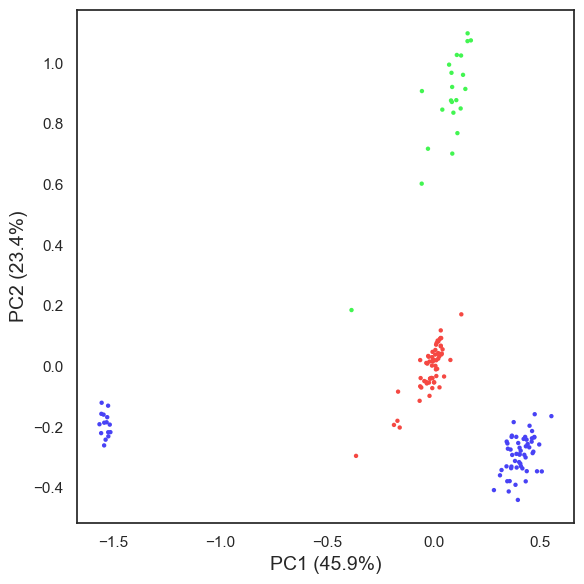

In [11]:
# Figure 5a — SmartSeq test cells latent space (model 5)
# SmartSeq test cells sit inside test_rep; extract them by position using sc_mask
sc_rep_z = dgd5.test_rep.z[sc_mask.values].clone().detach().cpu().numpy()
sc_labels    = sc_anno["cancer_type"].values
sc_color_map = dict(zip(sc_anno["cancer_type"], sc_anno["color"]))
gmm_means5   = dgd5.gmm.mean.clone().detach().cpu().numpy()
gmm_samples5 = dgd5.gmm.sample(1000).detach().cpu().numpy()

plot_latent_space_dataonly(
    sc_rep_z, gmm_means5, gmm_samples5,
    dgd5.gmm, sc_labels, sc_color_map,
    title="SmartSeq test (model 5)",
    savedir=savedir,
    filename="Figure 5a - SmartSeq test latent space (model 5).svg",
)


### Figure 6bc — PSCSR Latent Space (model 4b: TCGA+GTEx+R2)

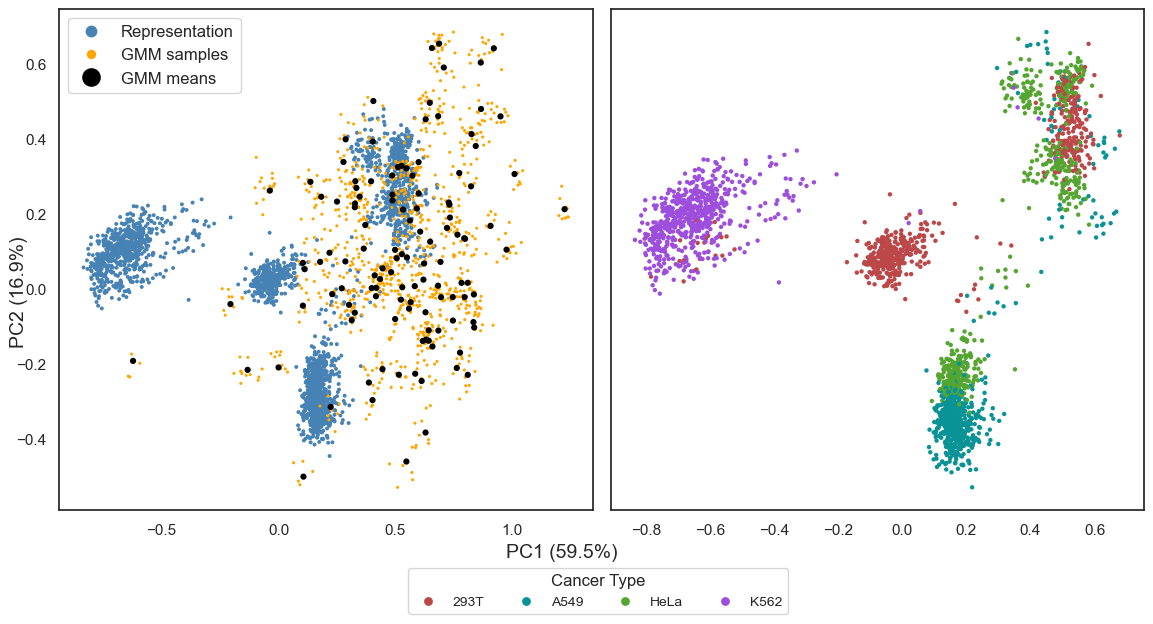

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [12]:
# Figure 6bc — PSCSR latent space from TCGA+GTEx+R2 model (model 4b)
pscsr_rep4b  = dgd4b.pscsr_rep.z.clone().detach().cpu().numpy()
gmm_means4b  = dgd4b.gmm.mean.clone().detach().cpu().numpy()
gmm_samples4b = dgd4b.gmm.sample(1000).detach().cpu().numpy()

plot_latent_space_ms(
    pscsr_rep4b, gmm_means4b, gmm_samples4b,
    dgd4b.gmm, pscsr_labels, pscsr_color_map,
    data_loader=None, title="PSCSR (model 4b)",
    savedir=savedir,
    filename="Figure 6bc - PSCSR latent space (TCGA+GTEx+R2 model).svg",
)


### Supplementary Figure 8ab — PSCSR Latent Space (model 5: TCGA+GTEx+R2+SmartSeq)

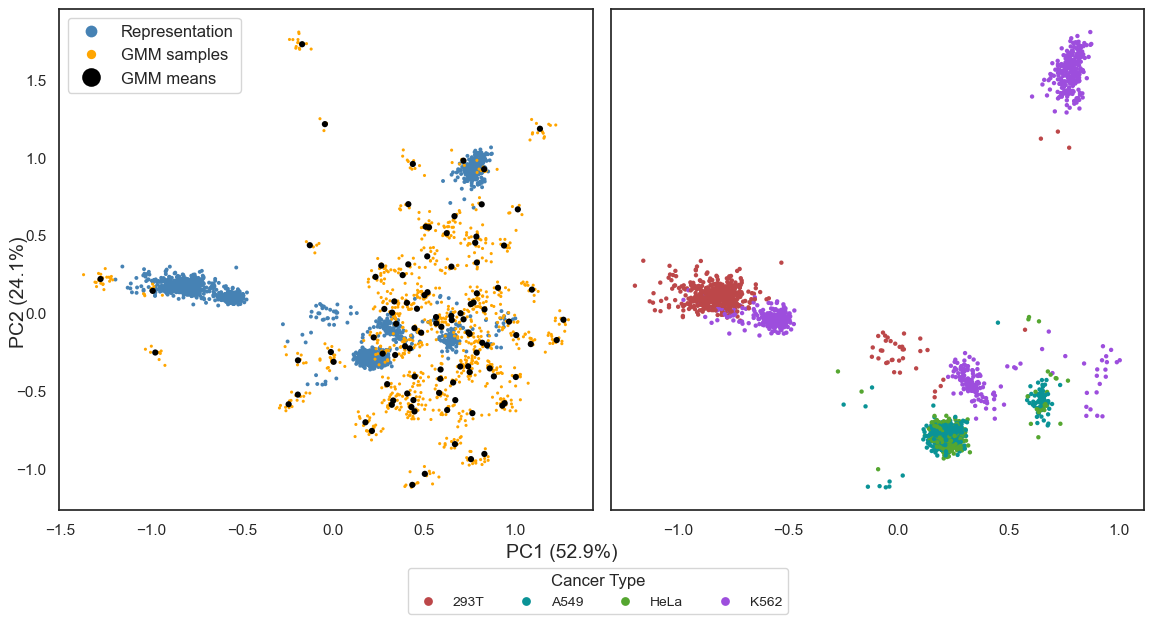

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [13]:
# Supplementary Figure 8ab — PSCSR latent space from model 5 (TCGA+GTEx+R2+SmartSeq)
pscsr_rep5   = dgd5.pscsr_rep.z.clone().detach().cpu().numpy()
gmm_means5_p = dgd5.gmm.mean.clone().detach().cpu().numpy()
gmm_samples5_p = dgd5.gmm.sample(1000).detach().cpu().numpy()

plot_latent_space_ms(
    pscsr_rep5, gmm_means5_p, gmm_samples5_p,
    dgd5.gmm, pscsr_labels, pscsr_color_map,
    data_loader=None, title="PSCSR (model 5)",
    savedir=savedir,
    filename="Supplementary Figure 8ab - PSCSR latent space (model 5).svg",
)
